# Taller 3 – Árboles de Decisión
**Técnicas de Aprendizaje de Máquina**

---
## Contenido
1. **Ejercicio 1** – Regresión con AAPL (mercado accionario)
2. **Ejercicio 2** – Clasificación con Titanic + Interfaz Gradio

Autor: Ricardo Hurtado - Catalina Polo

---
# Ejercicio 1 – Regresión de precios del mercado accionario (AAPL)

## 1. Instalación de dependencias

In [ ]:
!pip install ydata-profiling gradio --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 2.0 MB/s eta 0:00:00


## 2. Carga de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente ✅')

Librerías cargadas correctamente ✅


## 3. Carga del dataset AAPL

In [ ]:
# Opción 1: cargar desde GitHub
url = 'https://raw.githubusercontent.com/oscar-bustos/javeriana-analitica/main/stockdata/AAPL.csv'
df = pd.read_csv(url)

print(f'Shape del dataset: {df.shape}')
df.head()

Shape del dataset: (890, 9)


,Open,High,Low,Close,Adj Close,Volume,SMA_50,SMA_200,Daily_Return
0,118.720001,121.199997,118.150002,120.709999,118.099770,112559200,116.922999,88.593500,-0.003961
1,121.279999,121.550003,118.809998,119.019997,116.446327,115393800,117.025349,88.813162,-0.014001
2,119.959999,120.419998,115.660004,115.980003,113.472046,120639300,117.122699,89.021275,-0.025542
3,116.199997,118.980003,115.629997,117.510002,114.968956,124423700,117.218349,89.234075,0.013192
4,116.669998,118.709999,116.449997,116.870003,114.342804,89946000,117.368250,89.445437,-0.005446


## 4. Análisis Exploratorio de Datos (EDA) con ydata-profiling y Pandas

In [ ]:
# ── Reporte con ydata-profiling ──────────────────────────────────────────────
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title='Reporte EDA – AAPL', explorative=True, minimal=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 33.98it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# ── EDA manual con Pandas ────────────────────────────────────────────────────
print('=== Tipos de datos ===')
print(df.dtypes)

print('\n=== Estadísticas descriptivas ===')
display(df.describe())

print('\n=== Valores nulos por columna ===')
print(df.isnull().sum())

print('\n=== Duplicados ===')
print(f'Filas duplicadas: {df.duplicated().sum()}')

=== Tipos de datos ===
Open            float64
High            float64
Low             float64
Close           float64
Adj Close       float64
Volume            int64
SMA_50          float64
SMA_200         float64
Daily_Return    float64
dtype: object

=== Estadísticas descriptivas ===


,Open,High,Low,Close,Adj Close,Volume,SMA_50,SMA_200,Daily_Return
count,890.000000,890.000000,890.000000,890.000000,890.000000,8.900000e+02,890.000000,890.000000,890.000000
mean,155.915731,157.608472,154.342146,156.042629,154.472434,7.931075e+07,154.548239,146.841619,0.000533
std,21.558258,21.538907,21.592032,21.587516,22.071255,2.888945e+07,21.235720,23.426428,0.017367
min,109.110001,110.680000,107.320000,108.769997,106.417953,2.404830e+07,115.074600,88.593500,-0.058680
25%,139.497505,141.895000,137.370003,139.162498,137.630173,5.717378e+07,139.286249,132.349437,-0.008748
50%,153.769997,155.700005,152.080002,154.080002,152.709396,7.419030e+07,152.446300,152.137400,0.000361
75%,173.110004,175.075005,171.797501,173.637505,172.434353,9.353830e+07,172.362600,159.750400,0.010300
max,198.020004,199.619995,197.000000,198.110001,197.589523,1.954327e+08,190.925200,183.957300,0.088975



=== Valores nulos por columna ===
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
SMA_50          0
SMA_200         0
Daily_Return    0
dtype: int64

=== Duplicados ===
Filas duplicadas: 0


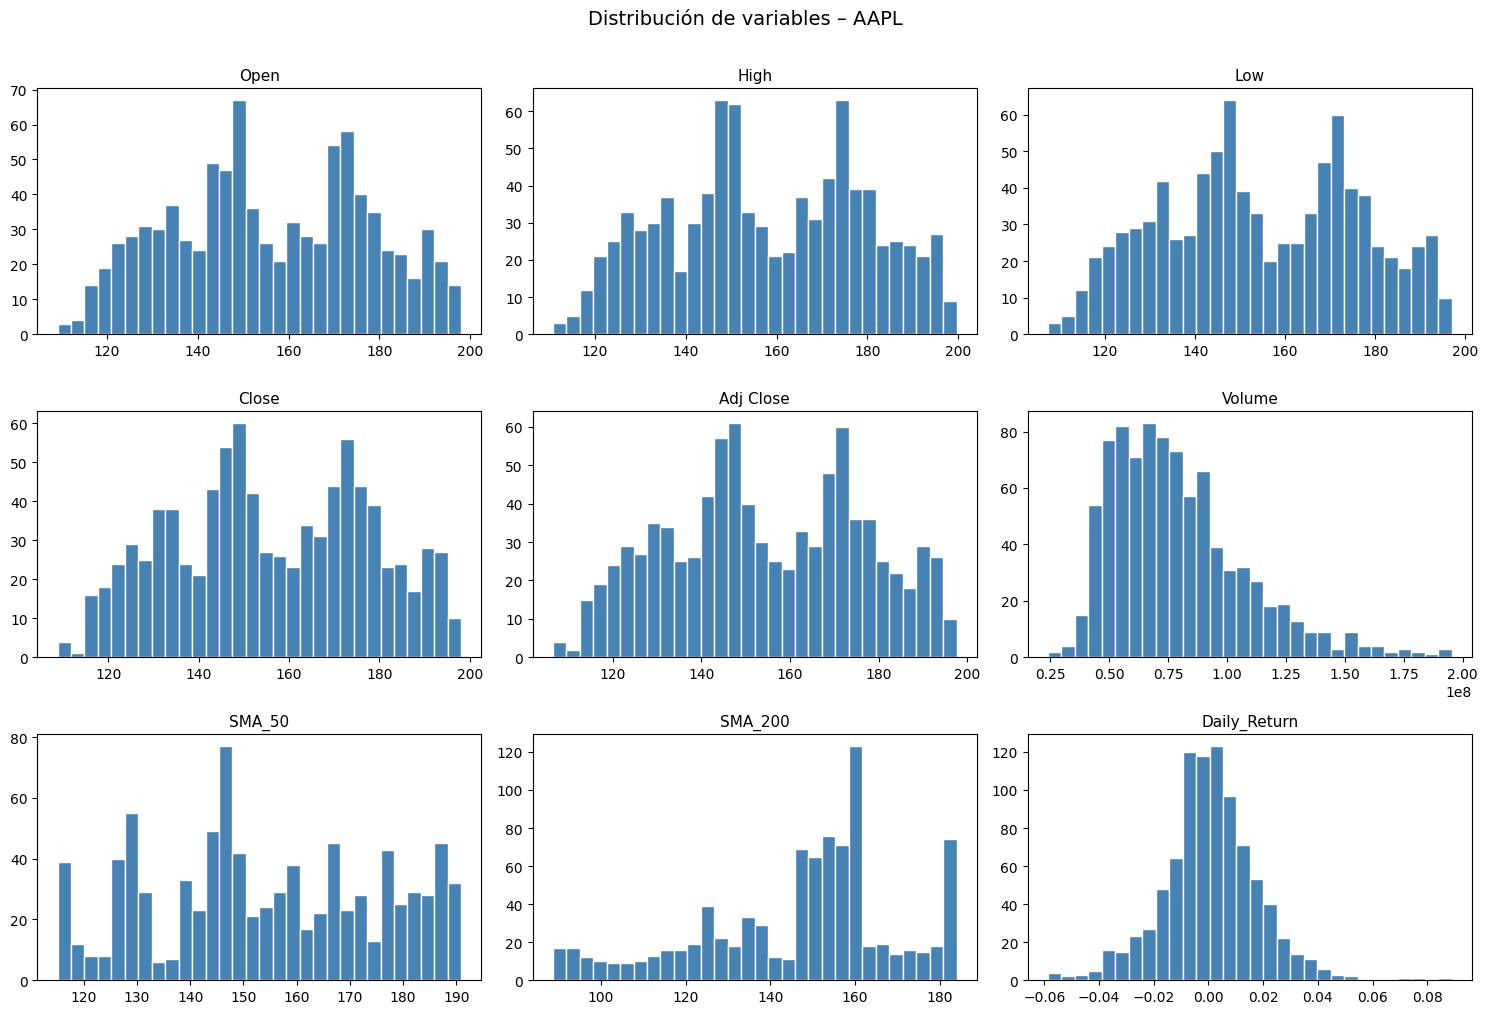

In [ ]:
# ── Visualizaciones EDA ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Distribución de variables – AAPL', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

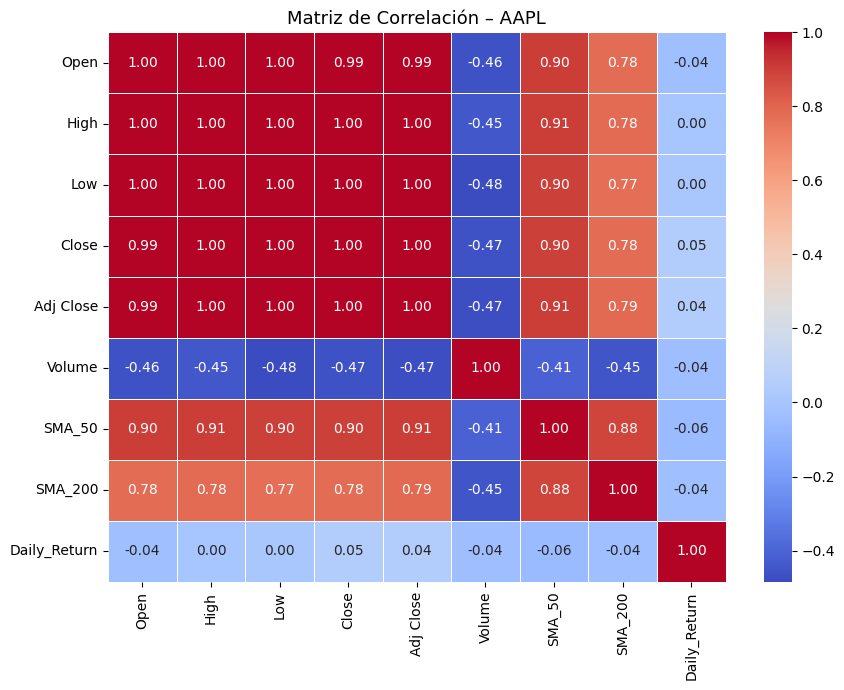

In [ ]:
# Mapa de correlación
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación – AAPL', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Limpieza de datos

> **Análisis:** El dataset AAPL no presenta valores nulos ni duplicados. Todas las variables son numéricas continuas, por lo que no se requiere codificación de variables categóricas. Se eliminan filas con NaN por precaución y se verifica que la variable objetivo `Daily_Return` no tenga outliers extremos que distorsionen el modelo.

In [ ]:
# Eliminar duplicados y nulos
df = df.drop_duplicates().dropna()
print(f'Shape luego de limpieza: {df.shape}')

# Revisar outliers en Daily_Return
q1 = df['Daily_Return'].quantile(0.01)
q99 = df['Daily_Return'].quantile(0.99)
print(f'Rango percentil 1-99 de Daily_Return: [{q1:.4f}, {q99:.4f}]')

# Mantenemos todos los datos pues los outliers son retornos reales del mercado
print('No se eliminan outliers: los valores extremos corresponden a eventos de mercado reales.')

Shape luego de limpieza: (890, 9)
Rango percentil 1-99 de Daily_Return: [-0.0428, 0.0413]
No se eliminan outliers: los valores extremos corresponden a eventos de mercado reales.


## 6. Separación de variables (X, Y) y split train/test

In [ ]:
# Paso 3 y 4 del enunciado
X = df.drop(columns=['Daily_Return'])
Y = df['Daily_Return']

print(f'X shape: {X.shape}')
print(f'Y shape: {Y.shape}')

# Paso 5: split 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=42
)
print(f'\nEntrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')

X shape: (890, 8)
Y shape: (890,)

Entrenamiento: 623 muestras
Prueba:        267 muestras


## 7. Entrenamiento de múltiples modelos DecisionTreeRegressor

In [ ]:
def eval_regressor(model, X_tr, X_te, y_tr, y_te, nombre):
    """Entrena el modelo y devuelve un dict con métricas train y test."""
    model.fit(X_tr, y_tr)
    resultados = {'Modelo': nombre}
    for tag, X_ev, y_ev in [('Train', X_tr, y_tr), ('Test', X_te, y_te)]:
        pred = model.predict(X_ev)
        resultados[f'MSE_{tag}']  = mean_squared_error(y_ev, pred)
        resultados[f'MAE_{tag}']  = mean_absolute_error(y_ev, pred)
        resultados[f'R2_{tag}']   = r2_score(y_ev, pred)
    return resultados

configs = [
    # (nombre,  criterion,       max_depth, max_features, max_leaf_nodes, min_impurity_decrease, min_samples_leaf, min_samples_split)
    ('M1 – Default',             'squared_error', None,  None,    None,  0.0,    1,  2),
    ('M2 – Profundidad 3',       'squared_error',    3,  None,    None,  0.0,    1,  2),
    ('M3 – Profundidad 5',       'squared_error',    5,  None,    None,  0.0,    1,  2),
    ('M4 – Profundidad 10',      'squared_error',   10,  None,    None,  0.0,    1,  2),
    ('M5 – Criterion Friedman',  'friedman_mse',  None,  None,    None,  0.0,    1,  2),
    ('M6 – Criterion MAE',       'absolute_error',None,  None,    None,  0.0,    1,  2),
    ('M7 – max_features sqrt',   'squared_error', None, 'sqrt',   None,  0.0,    1,  2),
    ('M8 – max_leaf_nodes 20',   'squared_error', None,  None,      20,  0.0,    1,  2),
    ('M9 – min_impurity 0.0001', 'squared_error', None,  None,    None,  1e-4,   1,  2),
    ('M10 – min_samples_leaf 5', 'squared_error', None,  None,    None,  0.0,    5,  2),
    ('M11 – min_samples_split 10','squared_error',None,  None,    None,  0.0,    1, 10),
    ('M12 – Balanceado',         'squared_error',    5, 'sqrt',     30,  1e-5,   3,  5),
]

resultados_reg = []
modelos_reg    = []

for (nombre, crit, depth, mfeat, mleaf, mid, msl, mss) in configs:
    m = DecisionTreeRegressor(
        criterion=crit,
        max_depth=depth,
        max_features=mfeat,
        max_leaf_nodes=mleaf,
        min_impurity_decrease=mid,
        min_samples_leaf=msl,
        min_samples_split=mss,
        random_state=42
    )
    res = eval_regressor(m, X_train, X_test, y_train, y_test, nombre)
    resultados_reg.append(res)
    modelos_reg.append(m)

df_reg = pd.DataFrame(resultados_reg).set_index('Modelo')
display(df_reg.round(6))

,MSE_Train,MAE_Train,R2_Train,MSE_Test,MAE_Test,R2_Test
Modelo,,,,,,
M1 – Default,0.000000,0.000000,1.000000,0.000501,0.016414,-0.808679
M2 – Profundidad 3,0.000276,0.012603,0.114432,0.000300,0.012993,-0.085733
M3 – Profundidad 5,0.000245,0.011814,0.214162,0.000331,0.013472,-0.195601
M4 – Profundidad 10,0.000083,0.006421,0.732616,0.000461,0.015592,-0.665929
M5 – Criterion Friedman,0.000000,0.000000,1.000000,0.000502,0.016474,-0.815337
M6 – Criterion MAE,0.000000,0.000000,1.000000,0.000442,0.014779,-0.597494
M7 – max_features sqrt,0.000000,0.000000,1.000000,0.000413,0.015091,-0.492926
M8 – max_leaf_nodes 20,0.000208,0.011315,0.332618,0.000350,0.013434,-0.266097
M9 – min_impurity 0.0001,0.000312,0.013176,0.000000,0.000277,0.012526,-0.000035


## 8. Visualización comparativa de métricas

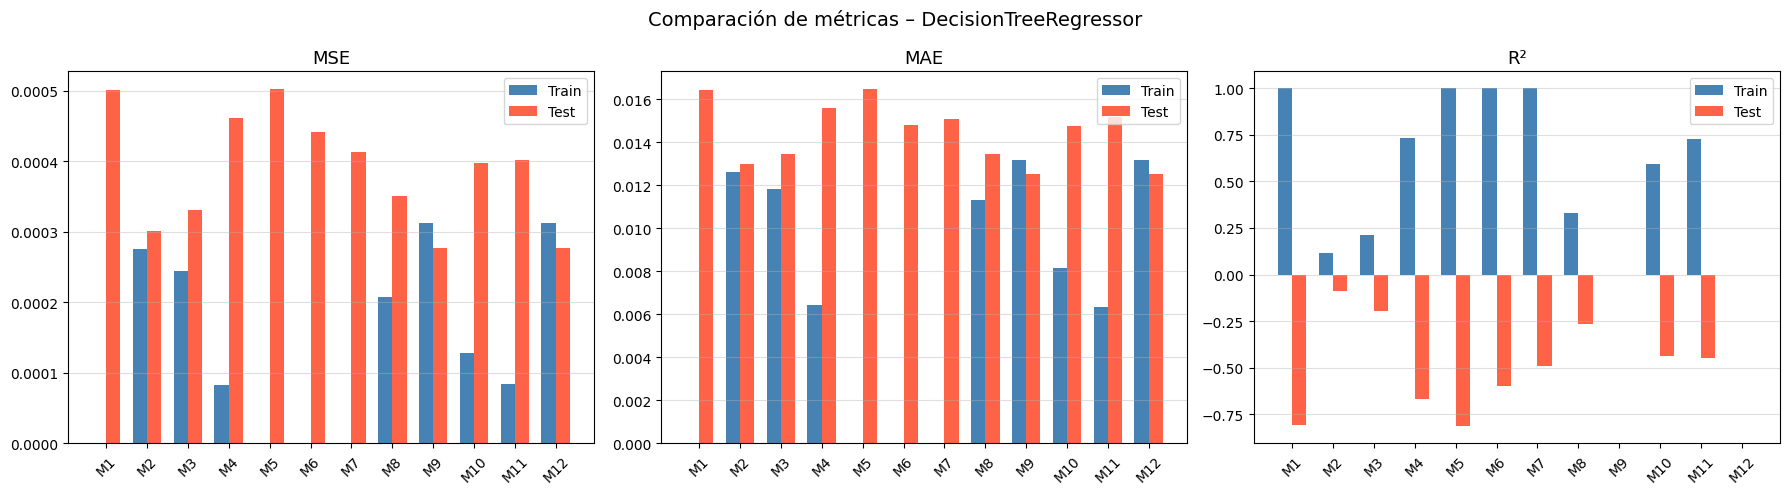

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metricas = [('MSE', 'MSE_Train', 'MSE_Test'),
            ('MAE', 'MAE_Train', 'MAE_Test'),
            ('R²',  'R2_Train',  'R2_Test')]

x = np.arange(len(df_reg))
w = 0.35

for ax, (titulo, col_tr, col_te) in zip(axes, metricas):
    ax.bar(x - w/2, df_reg[col_tr], w, label='Train', color='steelblue')
    ax.bar(x + w/2, df_reg[col_te], w, label='Test',  color='tomato')
    ax.set_title(titulo, fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([f'M{i+1}' for i in range(len(df_reg))], rotation=45)
    ax.legend()
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Comparación de métricas – DecisionTreeRegressor', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Análisis de resultados – Regresión AAPL

**Observaciones:**


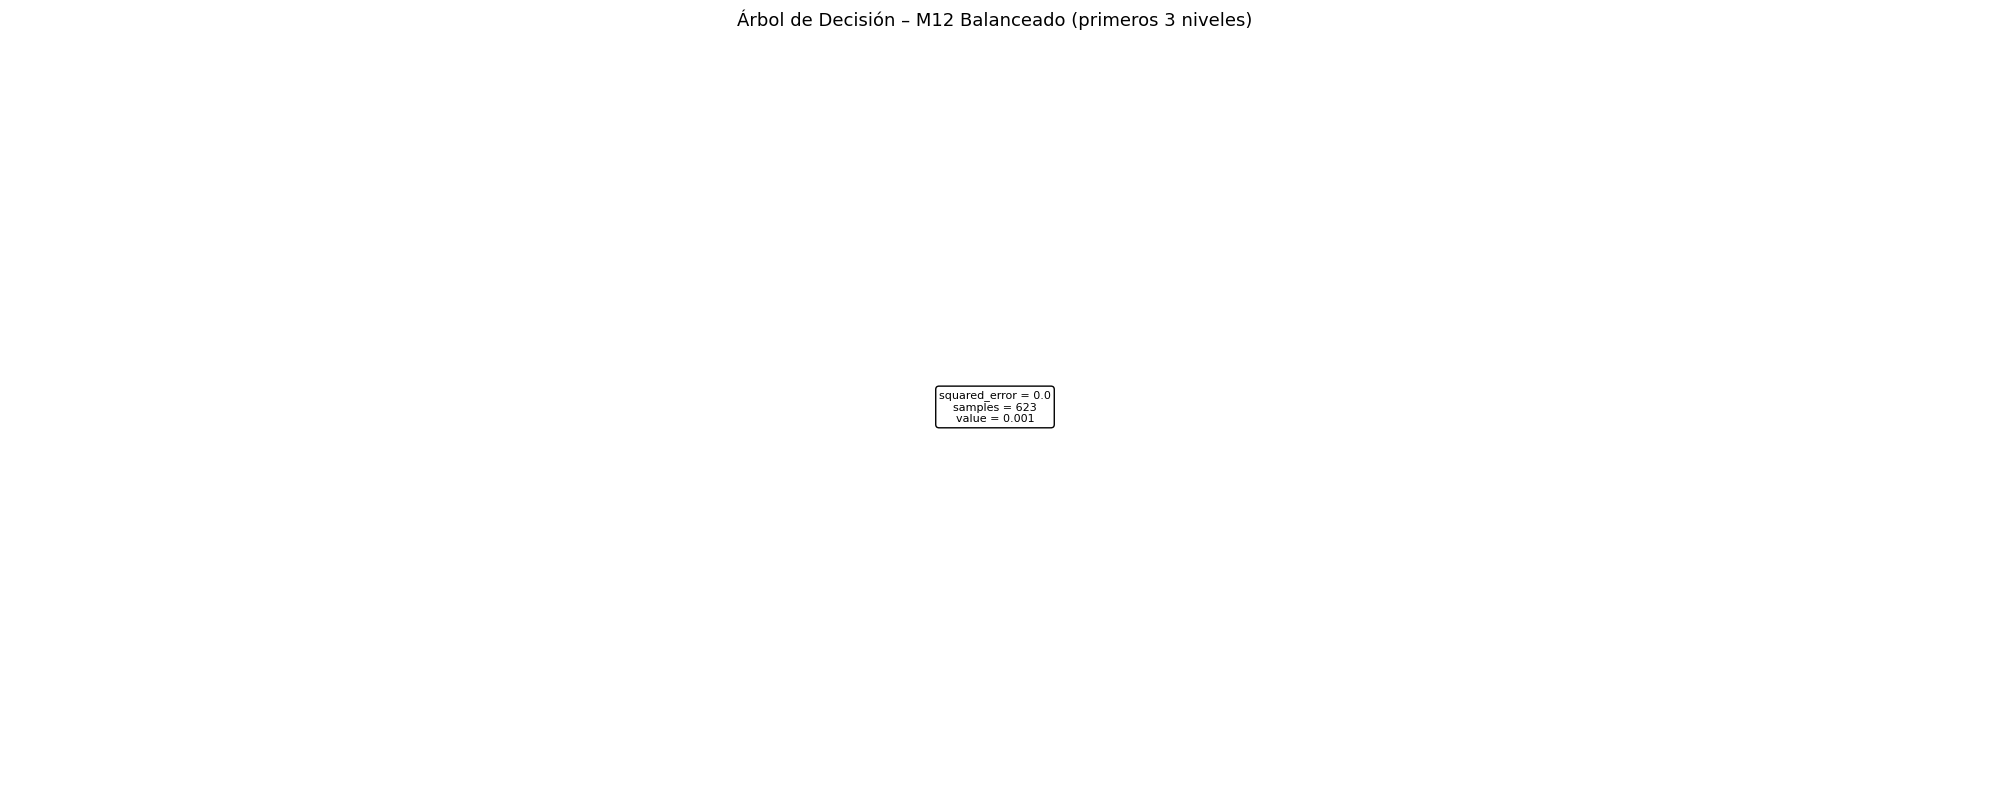

In [ ]:
# Visualizar el mejor modelo (M12 – Balanceado)
mejor_modelo_reg = modelos_reg[11]  # M12

plt.figure(figsize=(20, 8))
plot_tree(mejor_modelo_reg, feature_names=X.columns.tolist(),
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('Árbol de Decisión – M12 Balanceado (primeros 3 niveles)', fontsize=13)
plt.tight_layout()
plt.show()

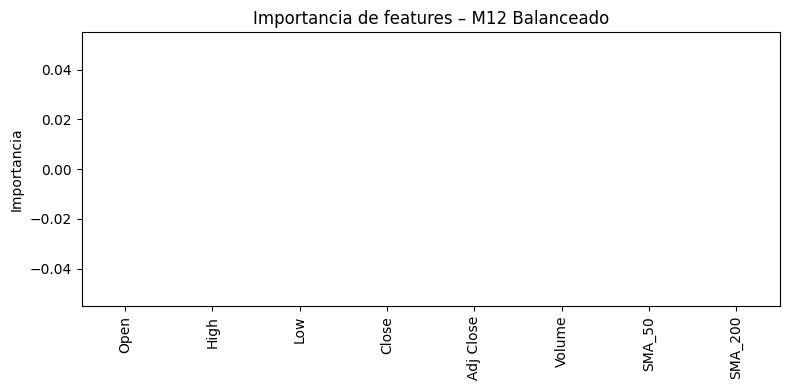

Open         0.0
High         0.0
Low          0.0
Close        0.0
Adj Close    0.0
Volume       0.0
SMA_50       0.0
SMA_200      0.0
dtype: float64


In [ ]:
# Importancia de features – M12
feat_imp = pd.Series(mejor_modelo_reg.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Importancia de features – M12 Balanceado', fontsize=12)
plt.ylabel('Importancia')
plt.tight_layout()
plt.show()
print(feat_imp)

---
# Ejercicio 2 – Clasificación con Titanic + Interfaz Gradio

## 1. Carga del dataset Titanic

In [ ]:
url_titanic = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df_titanic = pd.read_csv(url_titanic)

print(f'Shape original: {df_titanic.shape}')
df_titanic.head()

Shape original: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. EDA – Titanic

In [ ]:
print('=== Tipos de datos ===')
print(df_titanic.dtypes)

print('\n=== Valores nulos ===')
print(df_titanic.isnull().sum())

print('\n=== Estadísticas descriptivas ===')
display(df_titanic.describe())

=== Tipos de datos ===
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

=== Valores nulos ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

=== Estadísticas descriptivas ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


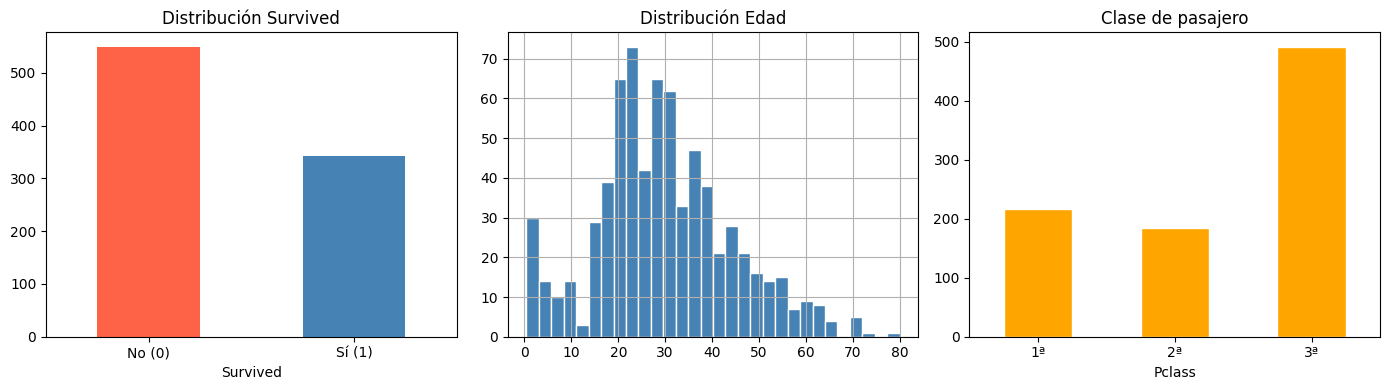

In [ ]:
# Distribución de supervivientes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df_titanic['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['tomato','steelblue'])
axes[0].set_title('Distribución Survived')
axes[0].set_xticklabels(['No (0)', 'Sí (1)'], rotation=0)

df_titanic['Age'].hist(bins=30, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Distribución Edad')

df_titanic['Pclass'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='orange', edgecolor='white')
axes[2].set_title('Clase de pasajero')
axes[2].set_xticklabels(['1ª', '2ª', '3ª'], rotation=0)

plt.tight_layout()
plt.show()

## 3. Limpieza de datos – Titanic

> Se eliminan valores nulos y se conservan únicamente variables numéricas, tal como indica el enunciado.

In [ ]:
# Seleccionar solo columnas numéricas
df_tit_num = df_titanic.select_dtypes(include=[np.number]).copy()
print(f'Columnas numéricas: {df_tit_num.columns.tolist()}')

# Eliminar nulos
df_tit_num = df_tit_num.dropna()
print(f'Shape luego de limpieza: {df_tit_num.shape}')
print(f'Nulos restantes: {df_tit_num.isnull().sum().sum()}')

Columnas numéricas: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Shape luego de limpieza: (714, 7)
Nulos restantes: 0


## 4. Separación train/test – Titanic

In [ ]:
X_tit = df_tit_num.drop(columns=['Survived'])
Y_tit = df_tit_num['Survived']

X_tit_train, X_tit_test, y_tit_train, y_tit_test = train_test_split(
    X_tit, Y_tit, test_size=0.30, random_state=42, stratify=Y_tit
)

print(f'Train: {X_tit_train.shape[0]} | Test: {X_tit_test.shape[0]}')
print(f'Distribución Y_train:\n{y_tit_train.value_counts()}')

Train: 499 | Test: 215
Distribución Y_train:
Survived
0    296
1    203
Name: count, dtype: int64


## 5. Entrenamiento de múltiples DecisionTreeClassifier

In [ ]:
def eval_classifier(model, X_tr, X_te, y_tr, y_te, nombre):
    model.fit(X_tr, y_tr)
    pred_te = model.predict(X_te)
    pred_tr = model.predict(X_tr)
    return {
        'Modelo':         nombre,
        'Acc_Train':      accuracy_score(y_tr, pred_tr),
        'Acc_Test':       accuracy_score(y_te, pred_te),
        'Precision_Test': precision_score(y_te, pred_te, zero_division=0),
        'Recall_Test':    recall_score(y_te, pred_te, zero_division=0),
        'F1_Test':        f1_score(y_te, pred_te, zero_division=0),
    }, model

configs_cls = [
    # (nombre,               criterion,    max_depth, max_features, max_leaf_nodes, min_imp_dec, min_s_leaf, min_s_split)
    ('C1 – Default',         'gini',       None,  None,    None,  0.0,  1,  2),
    ('C2 – Depth 3 Gini',    'gini',          3,  None,    None,  0.0,  1,  2),
    ('C3 – Depth 5 Gini',    'gini',          5,  None,    None,  0.0,  1,  2),
    ('C4 – Depth 10 Gini',   'gini',         10,  None,    None,  0.0,  1,  2),
    ('C5 – Entropy',         'entropy',    None,  None,    None,  0.0,  1,  2),
    ('C6 – Depth 5 Entropy', 'entropy',       5,  None,    None,  0.0,  1,  2),
    ('C7 – max_features sqrt','gini',      None, 'sqrt',   None,  0.0,  1,  2),
    ('C8 – max_leaf 20',     'gini',       None,  None,      20,  0.0,  1,  2),
    ('C9 – min_imp 0.001',   'gini',       None,  None,    None,  1e-3, 1,  2),
    ('C10 – min_s_leaf 5',   'gini',       None,  None,    None,  0.0,  5,  2),
    ('C11 – min_s_split 10', 'gini',       None,  None,    None,  0.0,  1, 10),
    ('C12 – Balanceado',     'entropy',       5, 'sqrt',     30,  1e-4, 3,  5),
]

resultados_cls = []
modelos_cls    = []

for (nombre, crit, depth, mfeat, mleaf, mid, msl, mss) in configs_cls:
    m = DecisionTreeClassifier(
        criterion=crit, max_depth=depth, max_features=mfeat,
        max_leaf_nodes=mleaf, min_impurity_decrease=mid,
        min_samples_leaf=msl, min_samples_split=mss,
        random_state=42
    )
    res, trained = eval_classifier(m, X_tit_train, X_tit_test, y_tit_train, y_tit_test, nombre)
    resultados_cls.append(res)
    modelos_cls.append(trained)

df_cls = pd.DataFrame(resultados_cls).set_index('Modelo')
display(df_cls.round(4))

,Acc_Train,Acc_Test,Precision_Test,Recall_Test,F1_Test
Modelo,,,,,
C1 – Default,1.0000,0.6512,0.5667,0.5862,0.5763
C2 – Depth 3 Gini,0.7555,0.7023,0.6620,0.5402,0.5949
C3 – Depth 5 Gini,0.7856,0.6791,0.6184,0.5402,0.5767
C4 – Depth 10 Gini,0.9539,0.6465,0.5632,0.5632,0.5632
C5 – Entropy,1.0000,0.6279,0.5422,0.5172,0.5294
C6 – Depth 5 Entropy,0.7695,0.6698,0.6000,0.5517,0.5749
C7 – max_features sqrt,1.0000,0.6093,0.5161,0.5517,0.5333
C8 – max_leaf 20,0.7936,0.6698,0.6429,0.4138,0.5035
C9 – min_imp 0.001,0.9760,0.6326,0.5488,0.5172,0.5325


## 6. Matriz de confusión – Mejor modelo

Mejor modelo por F1 Test: C2 – Depth 3 Gini


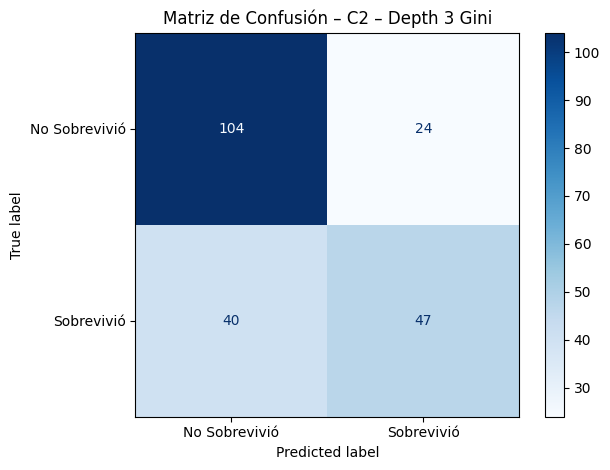

Accuracy:  0.7023
Precision: 0.6620
Recall:    0.5402
F1 Score:  0.5949


In [ ]:
# Seleccionar el modelo con mejor F1 en test
mejor_idx   = df_cls['F1_Test'].idxmax()
mejor_mod   = modelos_cls[df_cls.index.tolist().index(mejor_idx)]
print(f'Mejor modelo por F1 Test: {mejor_idx}')

pred_mejor = mejor_mod.predict(X_tit_test)

cm = confusion_matrix(y_tit_test, pred_mejor)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Sobrevivió', 'Sobrevivió'])
disp.plot(cmap='Blues')
plt.title(f'Matriz de Confusión – {mejor_idx}', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Accuracy:  {accuracy_score(y_tit_test, pred_mejor):.4f}")
print(f"Precision: {precision_score(y_tit_test, pred_mejor):.4f}")
print(f"Recall:    {recall_score(y_tit_test, pred_mejor):.4f}")
print(f"F1 Score:  {f1_score(y_tit_test, pred_mejor):.4f}")

## 7. Visualización del árbol – Mejor clasificador

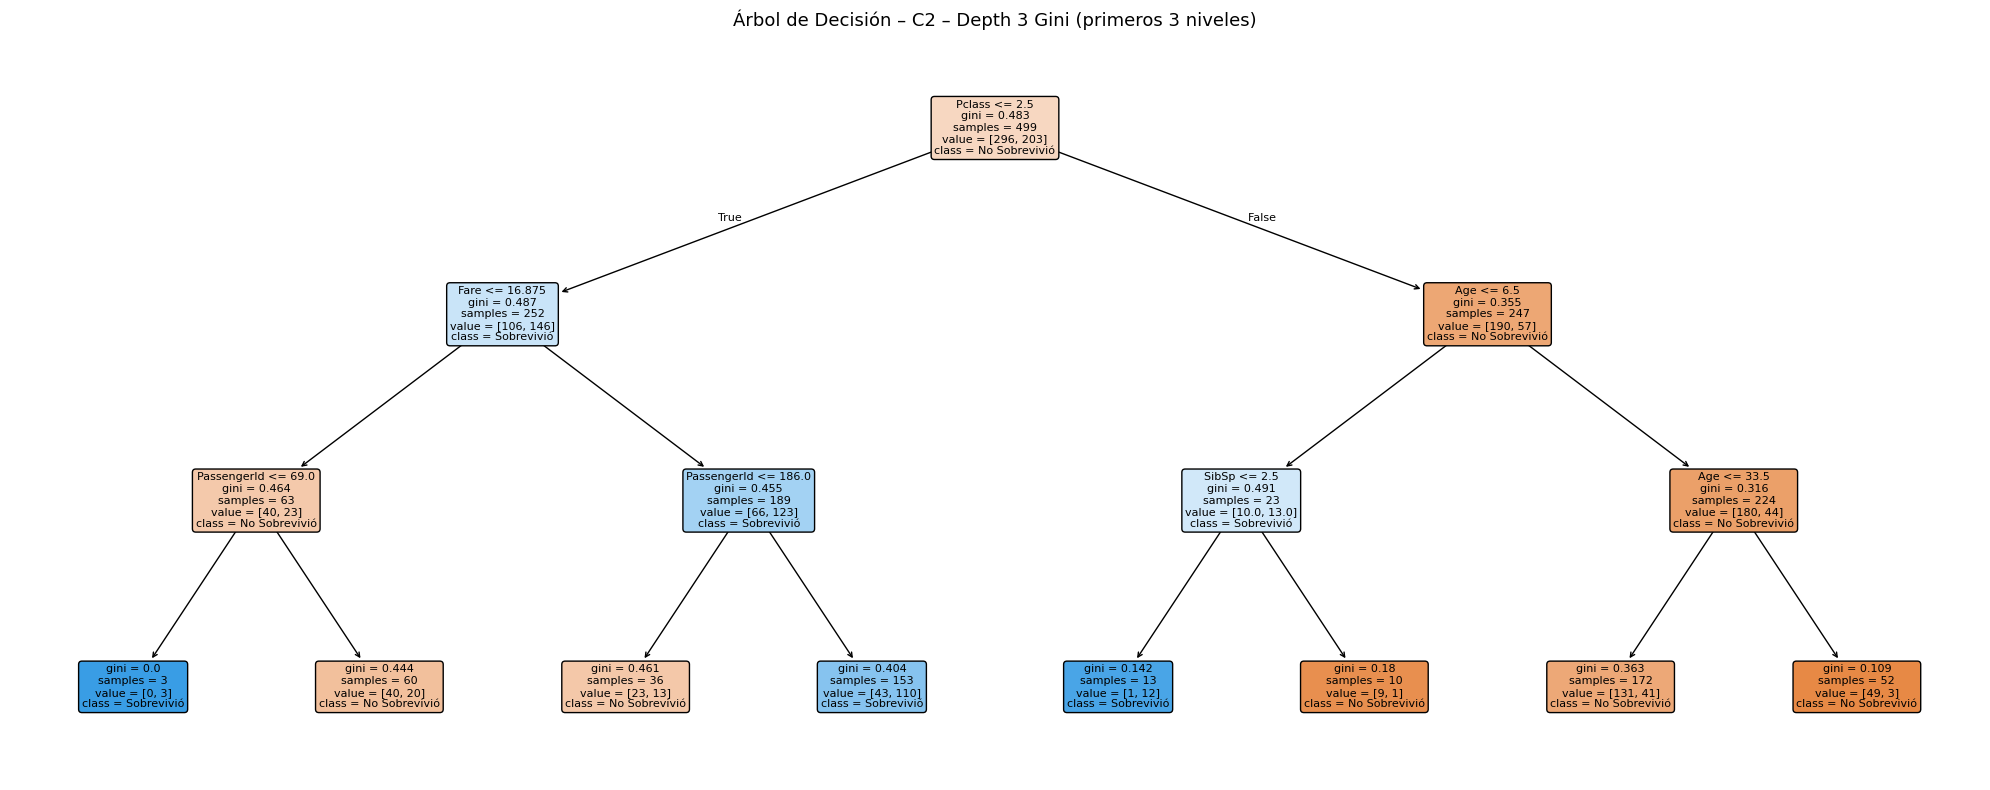

In [ ]:
plt.figure(figsize=(20, 8))
plot_tree(mejor_mod, feature_names=X_tit.columns.tolist(),
          class_names=['No Sobrevivió', 'Sobrevivió'],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title(f'Árbol de Decisión – {mejor_idx} (primeros 3 niveles)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Importancia de features – Titanic

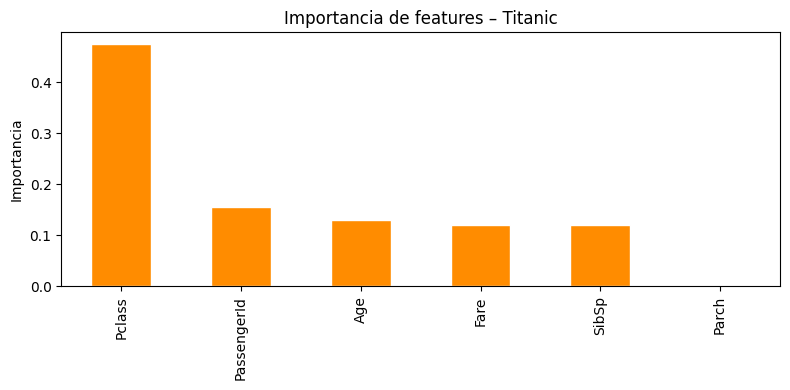

Pclass         0.473892
PassengerId    0.156369
Age            0.129441
Fare           0.120588
SibSp          0.119711
Parch          0.000000
dtype: float64


In [ ]:
feat_imp_tit = pd.Series(mejor_mod.feature_importances_, index=X_tit.columns)
feat_imp_tit = feat_imp_tit.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
feat_imp_tit.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Importancia de features – Titanic', fontsize=12)
plt.ylabel('Importancia')
plt.tight_layout()
plt.show()
print(feat_imp_tit)

## 9. Análisis de resultados – Titanic



## 10. Interfaz Gradio – Predicción de supervivencia Titanic

In [ ]:
import gradio as gr

# Re-entrenamos el mejor modelo con todos los datos para la demo
modelo_gradio = DecisionTreeClassifier(
    criterion='entropy', max_depth=5, max_features='sqrt',
    max_leaf_nodes=30, min_impurity_decrease=1e-4,
    min_samples_leaf=3, min_samples_split=5, random_state=42
)
modelo_gradio.fit(X_tit, Y_tit)

# Columnas usadas por el modelo (numéricas del Titanic)
features_tit = X_tit.columns.tolist()
print('Features del modelo:', features_tit)

Features del modelo: ['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [ ]:
def predecir_supervivencia(PassengerId, Pclass, Age, SibSp, Parch, Fare):
    """
    Recibe características del pasajero y devuelve la probabilidad de supervivencia.
    """
    entrada = pd.DataFrame([{
        'PassengerId': PassengerId,
        'Pclass':      Pclass,
        'Age':         Age,
        'SibSp':       SibSp,
        'Parch':       Parch,
        'Fare':        Fare,
    }])
    # Asegurar mismo orden de columnas
    entrada = entrada[features_tit]

    prob = modelo_gradio.predict_proba(entrada)[0]
    pred = modelo_gradio.predict(entrada)[0]

    resultado = f"{'🟢 SOBREVIVE' if pred == 1 else '🔴 NO SOBREVIVE'}\n"
    resultado += f"Probabilidad de supervivencia: {prob[1]*100:.1f}%\n"
    resultado += f"Probabilidad de fallecimiento: {prob[0]*100:.1f}%"
    return resultado


interfaz = gr.Interface(
    fn=predecir_supervivencia,
    inputs=[
        gr.Number(label='PassengerId',    value=1),
        gr.Slider(minimum=1, maximum=3, step=1, label='Clase (Pclass)',  value=3),
        gr.Slider(minimum=0, maximum=80, step=1, label='Edad (Age)',     value=30),
        gr.Slider(minimum=0, maximum=8,  step=1, label='Hermanos/Cónyuge (SibSp)', value=0),
        gr.Slider(minimum=0, maximum=6,  step=1, label='Padres/Hijos (Parch)',     value=0),
        gr.Number(label='Tarifa pagada (Fare)', value=32.0),
    ],
    outputs=gr.Textbox(label='Predicción', lines=3),
    title='🚢 Titanic – Predicción de Supervivencia',
    description=(
        'Ingresa las características del pasajero para obtener la predicción de supervivencia '
        'usando un Árbol de Decisión entrenado con el dataset Titanic.'
    ),
    examples=[
        [1, 1, 38, 1, 0, 71.28],   # Primera clase, adulto con familia
        [2, 3, 22, 1, 0, 7.25],    # Tercera clase, adulto joven
        [3, 1, 26, 0, 0, 211.34],  # Primera clase, joven solo
        [4, 3, 8,  3, 1, 21.07],   # Tercera clase, niño con familia
    ],
    theme=gr.themes.Soft()
)

interfaz.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ade0e5d194281f62e4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Conclusiones Generales

### Ejercicio 1 – Regresión AAPL


### Ejercicio 2 – Clasificación Titanic
